# Chapter 11 — Link Prediction and Edge Classification

Chapters 8 and 9 turned each **node** into a vector — by hand or by learning — and used it
to predict a label *on the node*. This chapter moves the question into the **space between
nodes**: given two people who are *not* connected, **will they be?** That is **link
prediction** — inferring the edges a graph is missing, or the ones it will grow next.
"People you may know", product recommendations, and predicted protein interactions are all
this one task.

Its sibling is **edge classification**: given an edge that *does* exist, what **kind** is
it? We already did a worked example in Chapter 4, where every Bitcoin-OTC edge carried a
**+ (trust)** or **− (distrust)** sign. The two tasks share one engine — *score a pair of
nodes* — and link prediction is just edge classification with the two classes **"edge"** and
**"non-edge"**. So the machinery below serves both.

The spine of the chapter is a single, easily-broken promise: **a link predictor is only as
trustworthy as the test you give it.** You cannot grade predictions of *missing* edges
against a graph that is missing them — so we will **hide real edges, predict them back, and
measure honestly.** Under that one fair test we race four families of predictor on the
**CollegeMsg** messaging network from Chapters 5–6:

1. **neighbourhood heuristics** — score a pair by the friends they share;
2. a **classifier** that combines those heuristics;
3. **Node2Vec embeddings** (Chapter 8) turned into edge features;
4. **matrix factorization** of the adjacency matrix.

The winner is a surprise that sends us straight back to Chapter 5. Chapter 12 then picks up
the thread with learning that needs few or no labels at all.

In [20]:
import warnings
warnings.filterwarnings("ignore")  # keep gensim/sklearn chatter out of the outputs

import random

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from node2vec import Node2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import NMF
from sklearn.metrics import roc_auc_score, roc_curve

import utils

random.seed(42)
np.random.seed(42)

## 11.1 Two Questions About a Pair of Nodes

Every method in this chapter starts the same way: take **two nodes** and compute a **score**
that says how edge-like that pair is. What we *do* with the score splits into the two tasks:

- **Link prediction** — the pair is *not* currently an edge. A high score says "this edge is
  missing, or about to form." Ranking all the non-edges by score is the whole game.
- **Edge classification** — the pair *is* an edge, and the score (or a small model) labels
  it: trust vs distrust, fraud vs normal, family vs colleague.

We spend the chapter on link prediction because it forces the harder question — *how do we
even know a predictor works?* — but everything transfers to edge classification by swapping
the target.

Let's build the intuition on a graph small enough to reason about by hand.

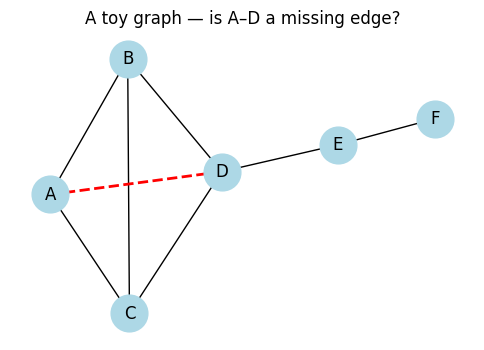

In [22]:
toy = nx.Graph()
toy.add_edges_from([("A", "B"), ("A", "C"), ("B", "C"),
                    ("B", "D"), ("C", "D"), ("D", "E"), ("E", "F")])

pos = nx.spring_layout(toy, seed=1)
plt.figure(figsize=(6, 4))
nx.draw_networkx(toy, pos, node_color="lightblue", node_size=700)
# the non-edge we suspect is "missing": A and D are not connected
nx.draw_networkx_edges(toy, pos, edgelist=[("A", "D")],
                       edge_color="red", style="dashed", width=2)
plt.title("A toy graph — is A–D a missing edge?")
plt.axis("off")
plt.show()

Look at **A** and **D**. They are not linked, yet both are friends with **B** and **C**.
Two nodes that share most of their neighbours are exactly the pairs a social network tends to
connect next — the friends-of-friends effect. Two classic scores make that precise:

- **Common neighbours** — just *count* the shared friends,
  $\mathrm{CN}(A,D) = \lvert N(A)\cap N(D)\rvert$. Here $N(A)=\{B,C\}$ and $N(D)=\{B,C,E\}$,
  so the shared set is $\{B,C\}$ and $\mathrm{CN}(A,D) = 2$.
- **Jaccard coefficient** — the *fraction* of their combined friends that is shared, so a
  low-degree pair is not unfairly beaten by a high-degree one:
  $J(A,D) = \dfrac{\lvert N(A)\cap N(D)\rvert}{\lvert N(A)\cup N(D)\rvert} = \dfrac{2}{3}
  \approx 0.67$.

Computed over *every* non-edge, Jaccard ranks **A–D top (0.67)** — its confident guess for
the missing link — with **F–D** a distant second (0.33; they share only E). The score has
turned a vague "looks missing" into a ranking.

### 🖐️ Your turn: the runner-up link

The top predicted link is A–D. Which non-edge does Jaccard rank **second**, and which
neighbour do those two nodes share?

In [24]:
# 🖐️ List every non-edge with its Jaccard score, sorted high to low, and read off the
#    runner-up (the second row). Which neighbour do those two nodes have in common?
# Hint: nx.jaccard_coefficient(toy) yields (u, v, score) triples for all non-edges.
scores = list(nx.jaccard_coefficient(toy))
# TODO: sort `scores` by the third element (descending) and print the top 3.
scores.sort(key=lambda x: x[2], reverse=True)
print(scores[:3])   # unsorted until you finish the line above

[('D', 'A', 0.6666666666666666), ('D', 'F', 0.3333333333333333), ('C', 'E', 0.25)]


## 11.2 A Family of Neighbourhood Scores

Common neighbours and Jaccard are two members of a whole family of **topological scores** —
each a different bet about *why* an edge appears. NetworkX ships them all. The five we use:

| Score | Formula | The bet it makes |
|---|---|---|
| **Common Neighbours** | $\lvert N(u)\cap N(v)\rvert$ | more shared friends → more likely |
| **Jaccard** | $\dfrac{\lvert N(u)\cap N(v)\rvert}{\lvert N(u)\cup N(v)\rvert}$ | *fraction* of friends shared (degree-fair) |
| **Adamic–Adar** | $\sum_{z\in N(u)\cap N(v)} \dfrac{1}{\log \lvert N(z)\rvert}$ | a shared *rare* friend counts more than a shared hub |
| **Resource Allocation** | $\sum_{z\in N(u)\cap N(v)} \dfrac{1}{\lvert N(z)\rvert}$ | same idea, punishes hubs harder |
| **Preferential Attachment** | $\lvert N(u)\rvert\cdot \lvert N(v)\rvert$ | **no shared friends at all** — just popularity × popularity |

The first four reward **shared neighbours**; **Preferential Attachment** is the odd one out —
it ignores overlap entirely and bets that two *popular* nodes will connect, the
"rich-get-richer" rule we met in the **Barabási–Albert** model of Chapter 5. Keep an eye on
it.

In [29]:
def neighbourhood_scores(G, u, v):
    cn = len(list(nx.common_neighbors(G, u, v)))
    ja = next(nx.jaccard_coefficient(G, [(u, v)]))[2]
    aa = next(nx.adamic_adar_index(G, [(u, v)]))[2]
    ra = next(nx.resource_allocation_index(G, [(u, v)]))[2]
    pa = next(nx.preferential_attachment(G, [(u, v)]))[2]
    return {"common_neighbours": cn, "jaccard": ja, "adamic_adar": aa,
            "resource_alloc": ra, "pref_attachment": pa}

pd.Series(neighbourhood_scores(toy, "A", "D"), name="A–D score").round(3)

common_neighbours    2.000
jaccard              0.667
adamic_adar          1.820
resource_alloc       0.667
pref_attachment      6.000
Name: A–D score, dtype: float64

### 🖐️ Your turn: popularity by hand

Preferential Attachment is just *degree times degree*. Without calling the scorer, predict
$\mathrm{PA}(D,F)$ from the toy graph, then check yourself.

In [30]:
# 🖐️ Preferential Attachment is |N(u)| * |N(v)|. Work out PA(D, F) in your head from the
#    drawing (how many neighbours does D have? and F?), then verify with one call.
# Hint: toy.degree("D") and toy.degree("F") give the two factors.
print("deg(D) =", toy.degree("D"), " deg(F) =", toy.degree("F"))
# TODO: state PA(D, F) as a number, then confirm with
#       next(nx.preferential_attachment(toy, [("D", "F")]))[2]

deg(D) = 3  deg(F) = 1


## 11.3 The Only Honest Test: Hide Edges and Win Them Back

On the toy graph we *eyeballed* that A–D was the missing link. On a real network with
thousands of non-edges we can eyeball nothing — and worse, we have **no answer key**: the
whole point is that the missing edges are *missing*. So how do we measure whether a score is
any good?

The trick is to **manufacture an answer key.** Take a real network, **hide a random slice of
its edges**, and challenge each score to rank those hidden edges *above* random pairs that
are genuinely not connected. The hidden edges are real, so we know they *should* score high —
they are our ground truth.

> **Hold edges out before you score them.** Computing a score on the graph that still
> contains the edge is cheating: the edge inflates its own endpoints' degrees and
> neighbourhoods, flattering every metric. The honest protocol scores on the *residual* graph
> and grades against the held-out edges.

Concretely:

1. Split the real edges into a **training** set (≈80%) and a **test** set (≈20%).
2. Build `G_train` from the training edges only — the graph every score is allowed to see.
3. Sample an equal number of **non-edges** as negative examples.
4. Score the held-out positives and the sampled negatives, and ask: does the score **rank
   positives above negatives**? That is exactly **ROC-AUC** (Chapter 9) — 1.0 is perfect,
   0.5 is a coin flip.

Our real network is **CollegeMsg** — private messages between UC Irvine students, the graph
we modelled in Chapters 5–6 — reduced to its undirected giant component.

In [31]:
url = "https://snap.stanford.edu/data/CollegeMsg.txt.gz"
file_path = utils.download_and_extract_data(zip_url=url, zip_filename=None, filetype="csv.gz")

# one row per message event: "sender receiver timestamp"; collapse to a simple graph
events = []
with open(file_path) as f:
    for line in f:
        parts = line.split()
        if len(parts) == 3:
            events.append((int(parts[0]), int(parts[1])))

G_college = nx.Graph()
G_college.add_edges_from((u, v) for u, v in events)
G_college = utils.get_giant_component(G_college).copy()
utils.print_graph_info(G_college)

Not running in Colab. Using local folder: /Users/boris/Documents/teaching/ML on graphs/ML-on-Graphs/data
Using data folder: /Users/boris/Documents/teaching/ML on graphs/ML-on-Graphs/data
ZIP file already exists.
Extraction complete.
Graph is undirected and unweighted.
Graph is connected.
Number of nodes:	  1,893
Number of edges:	 13,835
Density:		0.008


### Building the held-out split

The helper below runs the four steps. One wrinkle is worth a comment: removing 20% of the
edges can leave a few nodes with **no edges at all**, and a score (or an embedding) can say
nothing about a node it never sees. So after the split we hand each newly-isolated node
**one** of its edges back — a small, honest repair that keeps every node in play.

In [32]:
def make_link_prediction_split(G, test_frac=0.2, seed=42):
    """Hide test_frac of G's edges as positives; sample as many non-edges as negatives.

    Returns G_train (the residual graph) plus train/test lists of positive and negative pairs.
    """
    rng = random.Random(seed)
    edges = list(G.edges())
    rng.shuffle(edges)
    n_test = int(test_frac * len(edges))
    test_pos, train_pos = edges[:n_test], edges[n_test:]

    G_train = nx.Graph()
    G_train.add_nodes_from(G.nodes())          # keep every node...
    G_train.add_edges_from(train_pos)          # ...but only the training edges

    # repair: give each isolated node one of its held-out edges back
    held = set(test_pos)
    for node in [n for n in G_train.nodes() if G_train.degree(n) == 0]:
        for e in list(held):
            if node in e:
                G_train.add_edge(*e); held.discard(e); train_pos.append(e); break
    test_pos = list(held)

    # sample negatives: random pairs that are NOT edges of the full graph
    nodes = list(G.nodes())
    negatives = set()
    while len(negatives) < len(train_pos) + len(test_pos):
        a, b = rng.choice(nodes), rng.choice(nodes)
        if a == b:
            continue
        pair = (a, b) if a < b else (b, a)
        if not G.has_edge(*pair):
            negatives.add(pair)
    negatives = list(negatives)
    test_neg, train_neg = negatives[:len(test_pos)], negatives[len(test_pos):]
    return G_train, train_pos, train_neg, test_pos, test_neg


G_train, train_pos, train_neg, test_pos, test_neg = make_link_prediction_split(G_college)
print(f"G_train:  {G_train.number_of_nodes():,} nodes, {G_train.number_of_edges():,} edges")
print(f"test set: {len(test_pos):,} held-out edges  +  {len(test_neg):,} sampled non-edges")

G_train:  1,893 nodes, 11,159 edges
test set: 2,676 held-out edges  +  2,676 sampled non-edges


### Scoring the five heuristics

Now run each heuristic on `G_train`, score the held-out edges and an equal number of sampled
non-edges, and read off the ROC-AUC. The helper returns both the AUC and the ROC curve, so we
can plot the leaders later.

In [34]:
HEURISTICS = {
    "Common Neighbours":       lambda H, pairs: [(u, v, len(list(nx.common_neighbors(H, u, v)))) for u, v in pairs],
    "Jaccard":                 lambda H, pairs: nx.jaccard_coefficient(H, pairs),
    "Adamic–Adar":             lambda H, pairs: nx.adamic_adar_index(H, pairs),
    "Resource Allocation":     lambda H, pairs: nx.resource_allocation_index(H, pairs),
    "Preferential Attachment": lambda H, pairs: nx.preferential_attachment(H, pairs),
}

test_pairs = test_pos + test_neg
y_test = np.r_[np.ones(len(test_pos)), np.zeros(len(test_neg))]

def auc_and_curve(scorer):
    score = {(u, v): s for u, v, s in scorer(G_train, test_pairs)}
    y_score = np.array([score[p] for p in test_pairs])
    fpr, tpr, _ = roc_curve(y_test, y_score)
    return roc_auc_score(y_test, y_score), (fpr, tpr)

heuristic_auc, heuristic_curve = {}, {}
for name, scorer in HEURISTICS.items():
    heuristic_auc[name], heuristic_curve[name] = auc_and_curve(scorer)

pd.Series(heuristic_auc, name="ROC-AUC").sort_values(ascending=False).round(3)

Preferential Attachment    0.908
Resource Allocation        0.763
Adamic–Adar                0.762
Common Neighbours          0.758
Jaccard                    0.724
Name: ROC-AUC, dtype: float64

Read the leaderboard and a surprise jumps out. The four **shared-neighbour** scores land in
a tight band around **AUC ≈ 0.72–0.76** — useful, not stellar. **Preferential Attachment**,
which never even looks at shared friends, runs away with it at **AUC ≈ 0.91**.

On a *messaging* network that makes sense: who you message next is driven less by "friends of
friends" and more by **how active both of you are.** A heavy messager and another heavy
messager are very likely to exchange a message; two quiet accounts are not. That is exactly
the **rich-get-richer** mechanism behind the Barabási–Albert model of **Chapter 5** — and
here it out-predicts every neighbourhood heuristic.

> **The best feature is the one that matches how the graph actually grows.** On CollegeMsg
> that is popularity, not triadic closure.

In [36]:
# Why "hold out first" matters: score the SAME test edges on the full graph (edges left in).
def auc_on(graph, scorer):
    score = {(u, v): s for u, v, s in scorer(graph, test_pairs)}
    return roc_auc_score(y_test, [score[p] for p in test_pairs])

pa = HEURISTICS["Preferential Attachment"]
cn = HEURISTICS["Common Neighbours"]
print(f"Preferential Attachment  honest (G_train) = {auc_on(G_train, pa):.3f}   "
      f"leaky (full graph) = {auc_on(G_college, pa):.3f}")
print(f"Common Neighbours        honest (G_train) = {auc_on(G_train, cn):.3f}   "
      f"leaky (full graph) = {auc_on(G_college, cn):.3f}")

Preferential Attachment  honest (G_train) = 0.908   leaky (full graph) = 0.923
Common Neighbours        honest (G_train) = 0.758   leaky (full graph) = 0.800


Both scores look **better than they really are** when we leave the test edges in the graph
(Preferential Attachment climbs 0.91 → 0.92, common neighbours 0.76 → 0.80). The inflation is
modest here, but it is *free, undeserved* AUC — and on denser graphs it can be large enough to
dress a useless model up as a great one. **Always score on the residual graph.**

### 🖐️ Your turn: tilt the class balance

We graded against an *equal* number of non-edges. Real graphs have **vastly** more non-edges
than edges. Re-grade Preferential Attachment against **five times** as many negatives as
positives and see what ROC-AUC does — and whether that surprises you.

In [45]:
# 🖐️ Build a bigger negative test set (~5x the positives) and recompute PA's ROC-AUC.
#    Does AUC move much? (ROC-AUC is famously robust to class imbalance — unlike precision.)
# Hint: reuse the Preferential Attachment scorer on G_train; label the extra non-edges 0.
extra_neg = test_neg + train_neg[: 4 * len(test_pos)]   # ~5x negatives, all genuine non-edges
big_pairs = test_pos + extra_neg
y_big = np.r_[np.ones(len(test_pos)), np.zeros(len(extra_neg))]
# TODO: score big_pairs with the PA scorer on G_train and print roc_auc_score(y_big, scores).
print(len(test_pos), "positives vs", len(extra_neg), "negatives")

2676 positives vs 13380 negatives


## 11.4 Don't Pick One Score — Learn to Combine Them

Each heuristic is a single opinion. Why choose? Stack all five into a **feature vector** for
every pair and let a classifier learn how to weigh them — the same "turn examples into rows,
then train" move from Chapter 9, except now a *row is a pair of nodes* rather than a single
node.

We compute the five scores on `G_train` for the **training** pairs (the observed edges plus
sampled non-edges) and for the held-out **test** pairs, then fit a logistic regression and a
random forest.

In [54]:
def feature_matrix(H, pairs):
    """Five neighbourhood scores per pair, as a (len(pairs), 5) array — computed on H."""
    cols = {
        name: {(u, v): s for u, v, s in scorer(H, pairs)}
        for name, scorer in HEURISTICS.items()
    }
    return np.array([[cols[name][p] for name in HEURISTICS] for p in pairs])

train_pairs = train_pos + train_neg
y_train = np.r_[np.ones(len(train_pos)), np.zeros(len(train_neg))]

X_train = feature_matrix(G_train, train_pairs)
X_test = feature_matrix(G_train, test_pairs)
print("feature matrix:", X_train.shape)

feature matrix: (22318, 5)


In [ ]:
# logistic regression needs the wildly-different score scales put on equal footing
scaler = StandardScaler().fit(X_train)
logreg = LogisticRegression(max_iter=1000).fit(scaler.transform(X_train), y_train)
forest = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train, y_train)

combined_auc = {
    "LogReg (5 heuristics)":       roc_auc_score(y_test, logreg.predict_proba(scaler.transform(X_test))[:, 1]),
    "RandomForest (5 heuristics)": roc_auc_score(y_test, forest.predict_proba(X_test)[:, 1]),
}
for k, v in combined_auc.items():
    print(f"{k:30s} AUC = {v:.3f}")

print("\nrandom-forest feature importances:")
print(pd.Series(forest.feature_importances_, index=list(HEURISTICS)).sort_values(ascending=False).round(3))

LogReg (5 heuristics)          AUC = 0.913
RandomForest (5 heuristics)    AUC = 0.903

random-forest feature importances:
Preferential Attachment    0.649
Adamic–Adar                0.136
Resource Allocation        0.128
Jaccard                    0.073
Common Neighbours          0.014
dtype: float64


The combined classifier reaches **AUC ≈ 0.91** — and barely beats Preferential Attachment
*alone* (0.908 → 0.913 for logistic regression). The feature-importance table explains why:
the forest hands **Preferential Attachment ≈ 0.65** of the importance and divides the rest
among the four neighbourhood scores. When one feature already captures how the graph grows,
combining adds polish, not a revolution.

> **A classifier is not magic.** It can only re-weight the signal already in its features — if
> one heuristic wins outright, "combine everything" mostly just rediscovers it.

### 🖐️ Your turn: which score carries the prediction? (~10 min)

The forest *says* Preferential Attachment dominates. Prove it with an **ablation**: retrain
the logistic-regression combiner **five times**, each time leaving one feature out, and record
the test AUC. Which feature's removal hurts most — and does it match the importance table?
Answer in a sentence.

In [13]:
# 🖐️ Drop one column at a time, refit LogReg on the remaining four, and record test AUC.
#    The biggest drop names the indispensable feature.
# Hint: for i in range(5): keep = [j for j in range(5) if j != i]; fit on X_train[:, keep].
names = list(HEURISTICS)
# TODO: build {dropped_feature_name: auc_without_it} and compare each to the full model (0.913).
print("full model AUC =", round(combined_auc["LogReg (5 heuristics)"], 3))

full model AUC = 0.913


<details><summary>Solution</summary>

```python
names = list(HEURISTICS)
ablation = {}
for i, name in enumerate(names):
    keep = [j for j in range(5) if j != i]
    sc = StandardScaler().fit(X_train[:, keep])
    clf = LogisticRegression(max_iter=1000).fit(sc.transform(X_train[:, keep]), y_train)
    ablation[f"without {name}"] = roc_auc_score(y_test, clf.predict_proba(sc.transform(X_test[:, keep]))[:, 1])
print(pd.Series(ablation).round(3))
```

Dropping any of the four neighbourhood scores leaves the AUC at **≈ 0.913** — they are
redundant with one another. Dropping **Preferential Attachment** alone collapses it to
**≈ 0.768.** One feature is doing essentially all the work, exactly as the importance table
warned: on CollegeMsg, popularity *is* the predictor.
</details>

## 11.5 Predicting From Learned Features: Embeddings and Factorization

The heuristics encode *our* theories of why edges form. The alternative — the Chapter 8
lesson — is to **learn** node features from the graph and let them speak. Two classic routes:

- **Node2Vec embeddings.** Embed every node into a 32-D vector with random walks (Chapter 8),
  then fuse a *pair* of node vectors into one *edge* vector. There are several ways to combine
  two vectors; we compare the **Hadamard** (element-wise product) and **average** operators.
  *(A graph neural network from Chapter 10 could supply the node vectors instead — the
  edge-feature step is identical.)*
- **Matrix factorization.** Factor the adjacency matrix $A \approx U V^{\top}$ into 32 latent
  factors per node (here with non-negative matrix factorization, **NMF**); the predicted score
  for a pair is the dot product of their latent vectors.

Both are trained on `G_train` **only**, so the held-out edges stay unseen.

In [56]:
# workers=1 + seed -> a fully reproducible embedding (~15 s to fit)
node2vec = Node2Vec(G_train, dimensions=32, walk_length=20, num_walks=30,
                    p=1, q=1, workers=1, seed=42, quiet=True).fit(window=5, min_count=1, seed=42)

def edge_features(pairs, operator):
    e = lambda n: node2vec.wv[str(n)]
    if operator == "hadamard":
        return np.array([e(u) * e(v) for u, v in pairs])
    if operator == "average":
        return np.array([(e(u) + e(v)) / 2 for u, v in pairs])
    raise ValueError(operator)

embedding_auc, embedding_curve = {}, {}
for operator in ["hadamard", "average"]:
    Xtr = edge_features(train_pairs, operator)
    Xte = edge_features(test_pairs, operator)
    sc = StandardScaler().fit(Xtr)
    clf = LogisticRegression(max_iter=1000).fit(sc.transform(Xtr), y_train)
    proba = clf.predict_proba(sc.transform(Xte))[:, 1]
    embedding_auc[f"Node2Vec + {operator}"] = roc_auc_score(y_test, proba)
    embedding_curve[f"Node2Vec + {operator}"] = roc_curve(y_test, proba)[:2]

for k, v in embedding_auc.items():
    print(f"{k:22s} AUC = {v:.3f}")

Node2Vec + hadamard    AUC = 0.569
Node2Vec + average     AUC = 0.844


Two lessons. 

First, the **operator matters enormously**: the *same* embedding scores
**AUC ≈ 0.84 with the average operator but only ≈ 0.57 with Hadamard** — a near coin-flip. The
"obvious" choice from the literature is not always right; the only way to know is to test (a
perfect job for the bonus exercises). 

Second, even the *good* embedding (0.84) lands **below**
Preferential Attachment (0.91). The learned features are competitive and need no hand-design —
but on this graph they do not beat the one heuristic that nails its growth rule.

In [58]:
nodes = list(G_train.nodes())
index = {n: i for i, n in enumerate(nodes)}
A = nx.adjacency_matrix(G_train, nodelist=nodes)

nmf = NMF(n_components=32, init="nndsvd", random_state=42, max_iter=500)
U = nmf.fit_transform(A)      # node x factor
V = nmf.components_           # factor x node

nmf_score = np.array([float(U[index[u]] @ V[:, index[v]]) for u, v in test_pairs])
nmf_auc = roc_auc_score(y_test, nmf_score)
nmf_curve = roc_curve(y_test, nmf_score)[:2]
print(f"NMF (matrix factorization) AUC = {nmf_auc:.3f}")

NMF (matrix factorization) AUC = 0.842


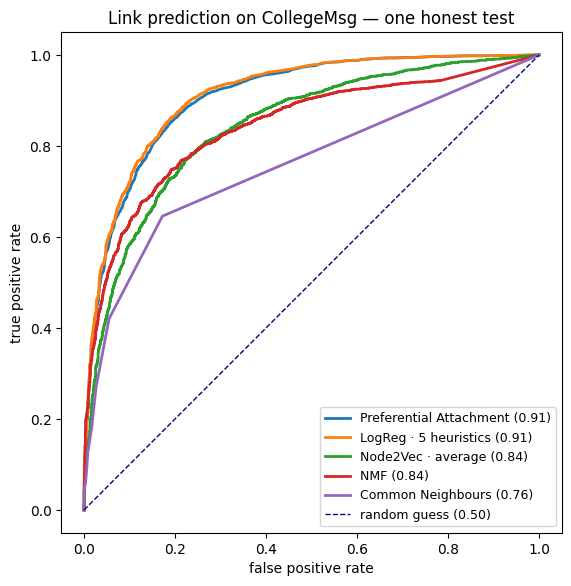

In [59]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.set_aspect("equal")

to_plot = [
    (f"Preferential Attachment ({heuristic_auc['Preferential Attachment']:.2f})", heuristic_curve["Preferential Attachment"]),
    (f"LogReg · 5 heuristics ({combined_auc['LogReg (5 heuristics)']:.2f})",       roc_curve(y_test, logreg.predict_proba(scaler.transform(X_test))[:, 1])[:2]),
    (f"Node2Vec · average ({embedding_auc['Node2Vec + average']:.2f})",            embedding_curve["Node2Vec + average"]),
    (f"NMF ({nmf_auc:.2f})",                                                        nmf_curve),
    (f"Common Neighbours ({heuristic_auc['Common Neighbours']:.2f})",               heuristic_curve["Common Neighbours"]),
]
for label, (fpr, tpr) in to_plot:
    ax.plot(fpr, tpr, lw=2, label=label)
ax.plot([0, 1], [0, 1], "navy", ls="--", lw=1, label="random guess (0.50)")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("Link prediction on CollegeMsg — one honest test")
ax.legend(loc="lower right", fontsize=9)
plt.show()

> **All four families beat chance, but the verdict is unambiguous: on CollegeMsg the cheap
> popularity heuristic (and the classifier that leans on it) wins, while the far more
> expensive learned embeddings trail it.** That is not a knock on embeddings; it is the
> chapter's real lesson. **Method choice is empirical.** A different graph — one where edges
> form by shared interest rather than popularity — would reshuffle this whole leaderboard,
> which is why we *always* run the honest test instead of trusting a favourite.

### 🖐️ Your turn: a better edge operator? (~10 min)

Hadamard and average are not the only ways to fuse two node vectors. Add the **concat** (stack
the two 32-D vectors into 64-D) and **L1** ($\lvert e(u) - e(v)\rvert$) operators, score each
with logistic regression on the same split, and rank all four. Does any operator unseat the
**average** result of ≈ 0.84 — and does any beat Preferential Attachment's 0.91?

In [17]:
# 🖐️ Extend edge_features with two more operators and compare all four by test AUC.
#    concat -> np.concatenate([e(u), e(v)]) ; L1 -> np.abs(e(u) - e(v))
# Hint: copy the §11.5 fit loop and add the new operators to the list.
e = lambda n: node2vec.wv[str(n)]
n0, n1 = list(G_train.nodes())[:2]
print("one node vector:", e(n0).shape, " concat of two:", np.concatenate([e(n0), e(n1)]).shape)
# TODO: build {operator: test_auc} for ["hadamard", "average", "L1", "concat"] and print it.

one node vector: (32,)  concat of two: (64,)


<details><summary>Solution</summary>

```python
def edge_features_ext(pairs, operator):
    e = lambda n: node2vec.wv[str(n)]
    if operator == "hadamard": return np.array([e(u) * e(v) for u, v in pairs])
    if operator == "average":  return np.array([(e(u) + e(v)) / 2 for u, v in pairs])
    if operator == "L1":       return np.array([np.abs(e(u) - e(v)) for u, v in pairs])
    if operator == "concat":   return np.array([np.concatenate([e(u), e(v)]) for u, v in pairs])

ops_auc = {}
for op in ["hadamard", "average", "L1", "concat"]:
    Xtr, Xte = edge_features_ext(train_pairs, op), edge_features_ext(test_pairs, op)
    sc = StandardScaler().fit(Xtr)
    clf = LogisticRegression(max_iter=1000).fit(sc.transform(Xtr), y_train)
    ops_auc[op] = roc_auc_score(y_test, clf.predict_proba(sc.transform(Xte))[:, 1])
print(pd.Series(ops_auc).round(3))
```

You get roughly **concat 0.85, average 0.84, L1 0.82, hadamard 0.57.** 

The `concat` operator
edges out `average`, and every reasonable operator buries Hadamard — but **none reaches
Preferential Attachment's 0.91.** 

Better feature *engineering* on the embedding helps at the
margin; it does not overturn the popularity signal.
</details>

## Summary

- **Link prediction scores the pairs that are *not* edges; edge classification labels the
  pairs that *are*.** Both reduce to one move — score a node pair — so the same toolkit serves
  both (Chapter 4's signed edges were edge classification).
- **You cannot grade a link predictor on the graph it learned from.** Hide a slice of real
  edges, rebuild the residual graph, sample non-edges, and measure **ROC-AUC** on the held-out
  pairs. Leaving the edges in inflates every score.
- **Neighbourhood heuristics** (common neighbours, Jaccard, Adamic–Adar, resource allocation)
  bet on shared friends and scored **AUC ≈ 0.72–0.76** here. **Preferential Attachment** —
  pure popularity, the Chapter 5 rich-get-richer rule — won at **≈ 0.91**.
- **Combining the five heuristics** in a classifier reached **≈ 0.91**, barely above PA alone;
  an ablation showed PA carried almost all the signal (drop it and AUC falls to ≈ 0.77).
- **Learned features** — Node2Vec embeddings (≈ 0.84 with the *average* operator, ≈ 0.57 with
  Hadamard) and NMF factorization (≈ 0.84) — were competitive but did **not** beat the best
  heuristic on this graph. The **edge operator** mattered as much as the embedding.
- **The verdict is graph-specific.** Method choice is empirical: the honest held-out test, not
  a favourite algorithm, tells you which predictor to ship.
- **Forward:** Chapter 12 turns to **unsupervised and semi-supervised** learning, where labels
  are scarce or absent — pushing the "let the graph speak" idea further.

## 🌶️ Bonus exercises (only if time remains)

These are optional extensions for the end of class — pick whichever looks fun. Each is a bit
larger and more open-ended than the in-class "Your turn" tasks (~15–25 min), and both reuse
the split, helpers, and embedding already built above.

### 🌶️ Bonus 1 — Can a bigger embedding catch up?

Node2Vec lost to Preferential Attachment (0.84 vs 0.91), but we only tried **32** dimensions —
maybe the embedding was simply too small to hold the signal. Re-fit it with the **average**
operator across a range of sizes (say 8, 16, 32, 64, 128), record the test AUC for each, and
plot **AUC vs. dimensions**. Does more capacity ever close the gap to Preferential
Attachment's 0.91, or does it plateau? Give a one-line verdict.

In [18]:
# 🌶️ Sweep the embedding size and watch the AUC. Fit Node2Vec at each dimension with the
#    AVERAGE operator, score on the held-out split, and plot AUC vs. dimensions.
# Hint: loop over `dims`; inside, mirror the §11.5 fit + average-operator + LogReg code.
dims = [8, 16, 32, 64, 128]
pa_baseline = heuristic_auc["Preferential Attachment"]   # the line to beat
# TODO: build a list `aucs` (one AUC per dimension), then plot dims vs aucs and draw a
#       dashed horizontal line at pa_baseline. Does the curve ever cross it?
print("target to beat (Preferential Attachment):", round(pa_baseline, 3))

target to beat (Preferential Attachment): 0.908


<details><summary>Solution</summary>

```python
aucs = []
for d in dims:
    m = Node2Vec(G_train, dimensions=d, walk_length=20, num_walks=30,
                 p=1, q=1, workers=1, seed=42, quiet=True).fit(window=5, min_count=1, seed=42)
    e = lambda n: m.wv[str(n)]
    Xtr = np.array([(e(u) + e(v)) / 2 for u, v in train_pairs])
    Xte = np.array([(e(u) + e(v)) / 2 for u, v in test_pairs])
    sc = StandardScaler().fit(Xtr)
    clf = LogisticRegression(max_iter=1000).fit(sc.transform(Xtr), y_train)
    aucs.append(roc_auc_score(y_test, clf.predict_proba(sc.transform(Xte))[:, 1]))

plt.plot(dims, aucs, "o-", label="Node2Vec · average")
plt.axhline(pa_baseline, ls="--", color="red", label="Preferential Attachment")
plt.xscale("log", base=2); plt.xlabel("embedding dimensions"); plt.ylabel("test ROC-AUC")
plt.legend(); plt.show()
print(dict(zip(dims, np.round(aucs, 3))))
```

The AUC climbs from **≈ 0.81 at 8 dims to ≈ 0.86 around 64 dims, then flattens** (128 is no
better than 64). More capacity buys a few points and then saturates — the embedding **never
reaches Preferential Attachment's 0.91**. The ceiling is not the embedding's *size*; it is
that random walks encode *proximity*, while what predicts a CollegeMsg edge is raw
*popularity*.
</details>

### 🌶️ Bonus 2 — Where does popularity fail?

Preferential Attachment wins overall, but *every* model has a blind spot. Find the held-out
edges PA gets **wrong** — the real edges it scores *low* — and characterise them. Compare the
endpoint degrees of the edges PA ranks high ("caught") with those it ranks low ("missed"), and
draw the comparison. What kind of true edge does a popularity score systematically miss, and
why? One or two sentences.

In [19]:
# 🌶️ Split the held-out TRUE edges into the ones PA scores high vs low (cut at the median
#    PA over all test pairs), then compare the two groups' minimum endpoint degree.
# Hint: pa_test gives every test pair's PA score; min(G_train.degree(u), G_train.degree(v))
#       measures how "active" the quieter endpoint is.
pa_test = {(u, v): s for u, v, s in nx.preferential_attachment(G_train, test_pairs)}
threshold = np.median([pa_test[p] for p in test_pairs])
# TODO: for the held-out positives (test_pos), compute min-degree, split by pa_test >= threshold,
#       compare the two groups (medians + a histogram), and explain PA's blind spot.
print("PA decision threshold (median of test pairs):", round(threshold))

PA decision threshold (median of test pairs): 162


<details><summary>Solution</summary>

```python
mindeg = {p: min(G_train.degree(p[0]), G_train.degree(p[1])) for p in test_pos}
caught = [mindeg[p] for p in test_pos if pa_test[p] >= threshold]
missed = [mindeg[p] for p in test_pos if pa_test[p] <  threshold]
print(f"caught {len(caught)} edges, median min-degree {np.median(caught):.0f}")
print(f"missed {len(missed)} edges, median min-degree {np.median(missed):.0f}")

plt.hist([caught, missed], bins=range(0, 40, 2), label=["caught (high PA)", "missed (low PA)"])
plt.xlabel("min endpoint degree in G_train"); plt.ylabel("# held-out edges")
plt.legend(); plt.show()
```

PA catches ~2,200 held-out edges (median min-degree **18**) and misses ~460 (median min-degree
**4**). The missed edges are overwhelmingly **between two low-activity users**: their
degree-product is tiny, so popularity has nothing to grab onto — even though the edge is real.
A popularity predictor is structurally blind to links between quiet nodes, exactly where a
*shared-neighbour* score (or content features) would have to step in.
</details>

## Chapter 11 — Link Prediction and Edge Classification · Homework

Work in a copy of this notebook and reuse its split, helpers, and `HEURISTICS`. Hand in your
code, any figures, and **a sentence or two of interpretation per part**.

### Part A — Which score carries it, on a forest?
The §11.4 ablation used logistic regression. Repeat it for the **random forest**: drop each
heuristic, refit, and record test AUC. Does the forest agree with the logistic model that
Preferential Attachment is indispensable, or does its non-linearity lean on the neighbourhood
scores more? Explain the difference you see.

### Part B — Does popularity still win on a different graph?
Re-run the whole pipeline (split → five heuristics → AUC) on the **email-Eu-core** network
from Chapter 3 (`data/email-Eu-core.txt`, undirected giant component). Which heuristic wins
*there*? If the ranking differs from CollegeMsg, what does that say about how the two networks
grow — collaboration/email vs. messaging?

### Part C — From link prediction to edge classification
You now have an engine that scores node pairs. Sketch — in a short paragraph, with a tiny code
stub if you like — how you would turn it into **edge classification** on Chapter 4's signed
**Bitcoin-OTC** network, where each existing edge is **+** (trust) or **−** (distrust). What
stays the same (features per pair), what changes (the target, the negative sampling), and why
is there no "hold edges out" step this time?